In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [50]:
#CONSTANTS
c = 299792458.0
e = 1.60217663e-19
eps0 = 8.854187812e-12
m_e_MeV = 0.51099895

In [51]:
#ARES ENERGY PARAMETERS
E_MeV = 100
E_total = E_MeV + m_e_MeV
gamma = E_total / m_e_MeV
beta = np.sqrt(1 - 1 / gamma**2)
v = beta * c

In [52]:
#ARES CHARGE PARAMETERS
bunchcharge = 5e-12
Ne = bunchcharge/e

In [53]:
#ARES BEAM PARAMETERS
sigma_x = sigma_y = 1e-3

In [54]:
#TEMPORAL PULSE (in sec)
taus_fwhm_s_list = [1e-6, 1e-9, 1e-12, 1e-15]

In [55]:
#SIGMA Z FOR GAUSSIAN
sigma_t = taus_fwhm_s_list/ (2*np.sqrt(2*np.log(2)))
sigma_z = c * sigma_t

In [ ]:
#OBSERVATION GRIDS
Nangle, Nlam = 200, 500
th = np.linspace(-0.4, 0.4, Nangle)
lam = np.linspace(1e-6,1e-5, Nlam)
phi = np.linspace(0, 2*np.pi, Nangle, endpoint=False)
TH, LAM = np.meshgrid(th, lam, indexing='ij')
OMEGA = 2*np.pi*c/LAM

In [ ]:
#SINGLE ELECTRON SPECTRUM
A = e**2 / (4*np.pi * eps0 * c)
W1 = A*(beta**2 * np.sin(TH)**2) / (1.0 - beta**2 * np.cos(TH)**2)**2

In [ ]:
#BUILDING GAUSSIAN FORM FACTOR
def f2_gaussian(omega, theta, tau_fwhm_s, beta, sigma_x=1e-3, sigma_y=1e-3):
    # kx = k * np.sin(theta) * np.cos(phi)
    # ky = k * np.sin(theta) * np.sin(phi)
    sigma_t = tau_fwhm_s / (2*np.sqrt(2*np.log(2)))
    sigma_z = c * sigma_t

    k = omega / c
    # kz = k * (1.0 - beta*np.cos(theta))
    kz = k * (1/beta - np.cos(theta)) #check notes for this derivation

    # phi is set to zero
    # kx = k * np.sin(theta)
    # ky = 0

    #integrating wrt to phi from 0 to 2pi
    kx = 0
    ky = 0

    arg = (sigma_x**2) * kx**2 + (sigma_y**2) * ky**2 + (sigma_z**2) * kz**2
    return np.exp(-arg)

In [ ]:
#ELECTRON BUNCH SPECTRUM
Wn_list = []
for tau_s in taus_fwhm_s_list:
    F2 = f2_gaussian(OMEGA, TH, tau_s, beta)
    Wn_list.append(W1 * (Ne + Ne*(Ne-1)*F2))

Wn_list.append(W1 * (Ne + Ne*(Ne-1)*F2))
stack = np.stack(Wn_list, axis=0)
positive = stack[stack > 0]
vmin = np.percentile(positive, 1) if positive.size else 1e-30
vmax = stack.max()

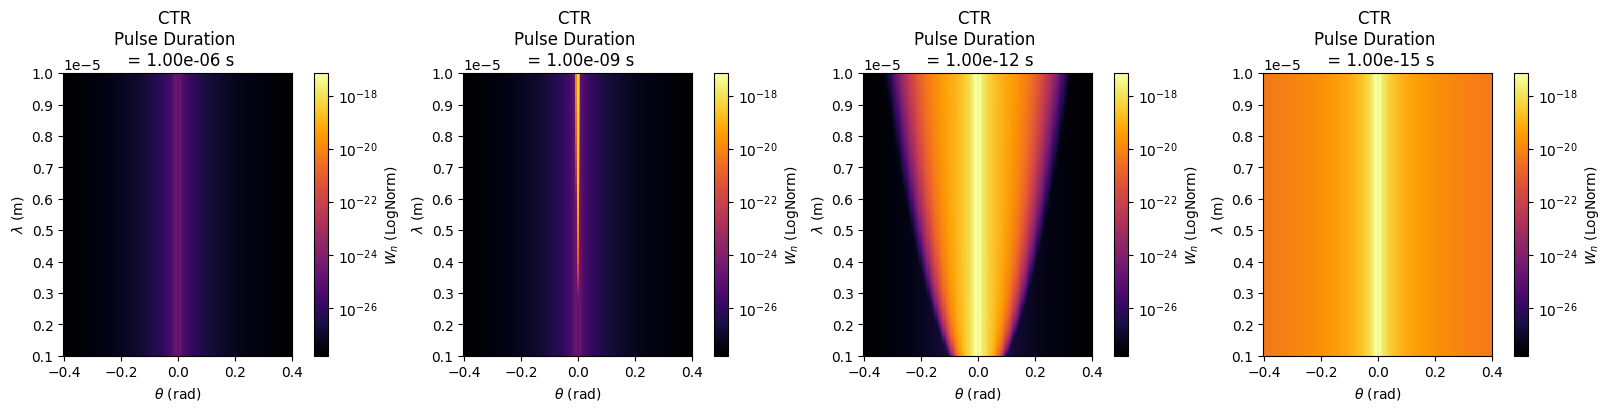

In [60]:
#PLOTTING
fig, axes = plt.subplots(1, len(taus_fwhm_s_list), figsize=(16,4), constrained_layout=True)
for ax, Wn, tau_s in zip(axes, Wn_list, taus_fwhm_s_list):
    im = ax.pcolormesh(th, lam, np.maximum(Wn.T, vmin), shading='nearest', cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_title(f'CTR \nPulse Duration \n = {tau_s:.2e} s')
    ax.set_xlabel(r'$\theta$ (rad)')
    ax.set_ylabel(r'$\lambda$ (m)')
    ax.set_ylim(lam.min(), lam.max())
    cb = plt.colorbar(im, ax=ax)
    cb.set_label(r'$W_n$ (LogNorm)')
plt.show()

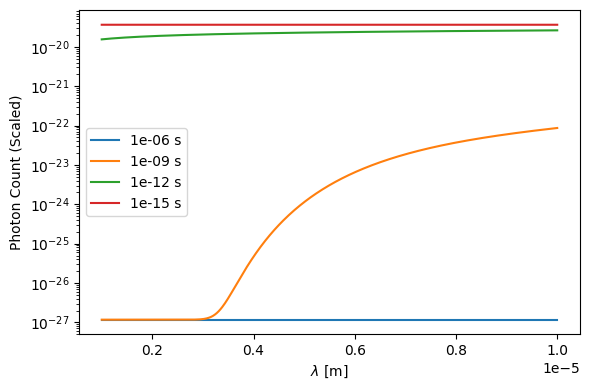

In [61]:
#INTEGRATION OF WN WITH RESPECT TO BIG OMEGA
jac = 2*np.pi*np.sin(TH)
Wn_int = [np.trapezoid(abs(Wn * jac), th, axis=0) for Wn in Wn_list]
ymax = max(w.max() for w in Wn_int)

plt.figure(figsize=(6,4))
for tau_s, y in zip(taus_fwhm_s_list, Wn_int):
    plt.plot(lam, y, label=f'{tau_s:.0e} s')
plt.yscale('log')
#plt.ylim(bottom=ymax*1e-6, top=ymax)
plt.xlabel(r'$\lambda$ [m]')
plt.ylabel('Photon Count (Scaled)')
plt.legend()
plt.tight_layout()
plt.show()